# Visualizing LeRobot Dataset Validation Results

This notebook visualizes the output of `scripts/validate_lerobot_dataset.py`. 

### Why Validate Robot Data?
Imitation Learning (IL) is fundamentally limited by the quality and consistency of the expert demonstrations. As highlighted in **Russ Tedrake's [Underactuated Robotics (Ch. 21)](https://underactuated.mit.edu/imitation.html)**, IL suffers from **Covariate Shift**: small errors in the policy accumulate, pushing the robot into states never seen during training. If the expert data is noisy or inconsistent, the model cannot learn a robust "manifold" to recover from these errors.

The script generates three main CSV files in the output directory (default: `dataset_validation_results`):
1. `within_episode_d1.csv`: Stationarity results for each dimension and episode.
2. `episode_metrics.csv`: Raw metrics per episode (length, variation, initial state).
3. `across_episode_drift.csv`: Kruskal-Wallis drift test results.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Ensure plots render inline
%matplotlib inline
sns.set_theme(style="whitegrid")

In [2]:
# =============================================================================
# CONFIGURATION
# =============================================================================
OUT_DIR = Path("../dataset_validation_results")
DIFF_ORDER = 1  # Should match the --diff-order used in the script
ALPHA = 0.05    # Significance level
STREAM = "action" # Stream to visualize in heatmap ("action" or "observation.state")
# =============================================================================

## Load Results

In [3]:
within_path = OUT_DIR / f"within_episode_d{DIFF_ORDER}.csv"
metrics_path = OUT_DIR / "episode_metrics.csv"
drift_path = OUT_DIR / "across_episode_drift.csv"

if not within_path.exists():
    print(f"❌ Could not find {within_path}.")
else:
    df_within = pd.read_csv(within_path)
    print(f"✅ Loaded within-episode results: {len(df_within)} rows")

if not metrics_path.exists():
    print(f"❌ Could not find {metrics_path}. Re-run script to generate.")
else:
    df_metrics = pd.read_csv(metrics_path)
    print(f"✅ Loaded episode metrics: {len(df_metrics)} rows")

if not drift_path.exists():
    print(f"❌ Could not find {drift_path}.")
else:
    df_drift = pd.read_csv(drift_path)
    print(f"✅ Loaded drift results: {len(df_drift)} rows")

✅ Loaded within-episode results: 10452 rows
✅ Loaded episode metrics: 201 rows
✅ Loaded drift results: 79 rows


## Phase 1: Signal Smoothness & Stationary Sampling

**Theoretical Context:** In **Cheng Chi's [Diffusion Policy presentation](https://www.youtube.com/watch?v=M03sZFfW-qU&t=129s)**, it is noted that Diffusion Policies learn to denoise expert trajectories. If the expert signal is non-stationary (jittery/noisy), the model may struggle to distinguish between the **expert signal** and the **Gaussian noise** added during the diffusion training process.

We use the **ADF (Augmented Dickey-Fuller)** and **KPSS** tests to ensure that action deltas are stationary. Ideally, robot actions should be **Stationary** or **Difference-Stationary**.

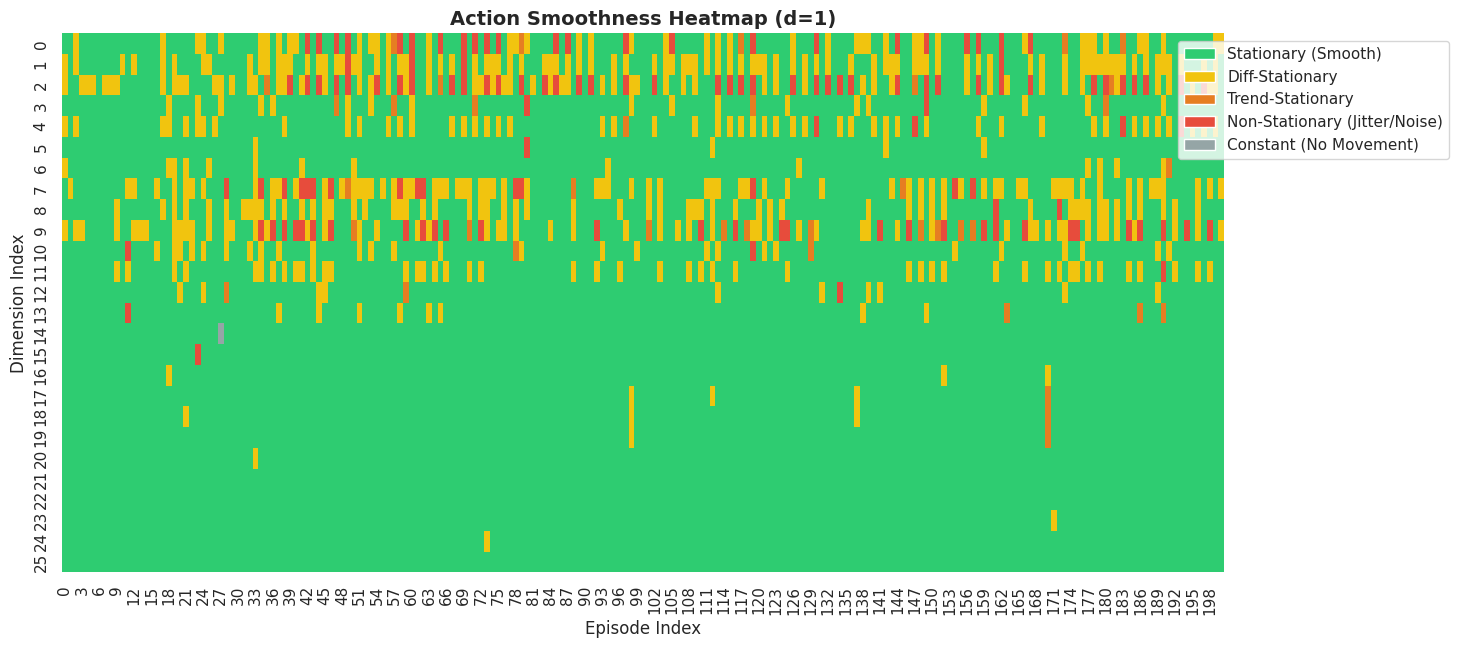

In [4]:
if 'df_within' in locals():
    df_stream = df_within[df_within["stream"] == STREAM].copy()
    
    if not df_stream.empty:
        verdict_map = {"stationary": 0, "difference_stationary": 1, "trend_stationary": 2, "non_stationary": 3, "constant": 4}
        df_stream["verdict_num"] = df_stream["verdict"].map(verdict_map)
        pivot_df = df_stream.pivot(index="dim", columns="episode", values="verdict_num")
        
        plt.figure(figsize=(15, 7))
        cmap = sns.color_palette(["#2ecc71", "#f1c40f", "#e67e22", "#e74c3c", "#95a5a6"])
        sns.heatmap(pivot_df, cmap=cmap, cbar=False, vmin=0, vmax=4)
        
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor="#2ecc71", label="Stationary (Smooth)"),
            Patch(facecolor="#f1c40f", label="Diff-Stationary"),
            Patch(facecolor="#e67e22", label="Trend-Stationary"),
            Patch(facecolor="#e74c3c", label="Non-Stationary (Jitter/Noise)"),
            Patch(facecolor="#95a5a6", label="Constant (No Movement)")
        ]
        plt.legend(handles=legend_elements, loc="upper right", bbox_to_anchor=(1.2, 1))
        plt.title(f"{STREAM.capitalize()} Smoothness Heatmap (d={DIFF_ORDER})", fontsize=14, fontweight="bold")
        plt.xlabel("Episode Index"); plt.ylabel("Dimension Index")
        plt.show()
    else:
        print(f"No data for stream: {STREAM}")

## Phase 2: Episode Metrics Over Time

Checking for trends in trajectory length and movement intensity (variation).

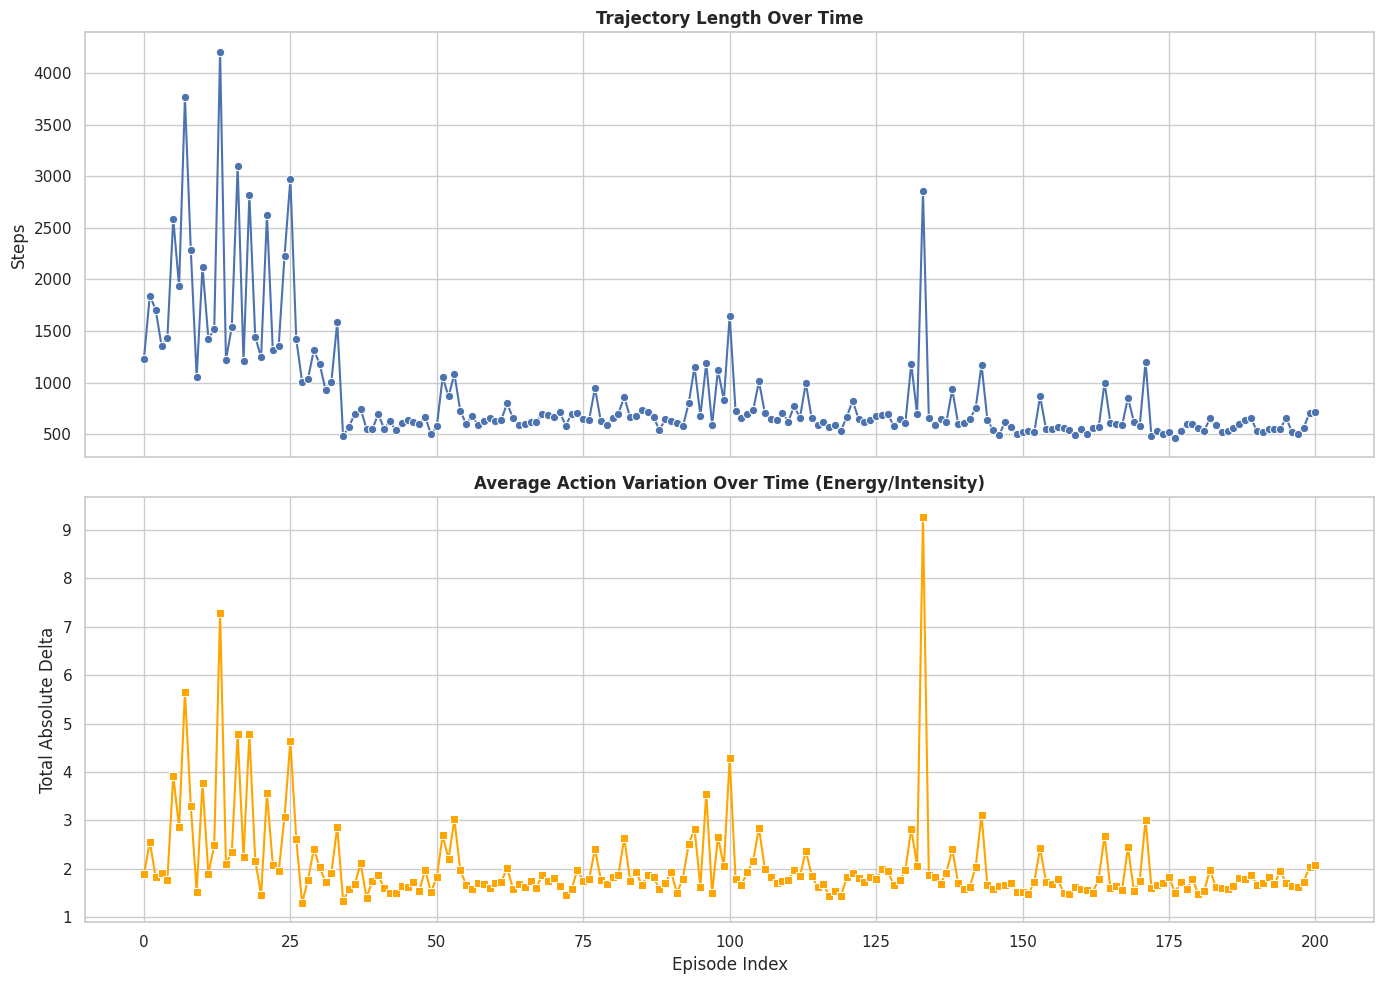

In [5]:
if 'df_metrics' in locals():
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
    
    # Trajectory Length
    sns.lineplot(data=df_metrics, x="episode", y="trajectory_length", ax=ax1, marker="o")
    ax1.set_title("Trajectory Length Over Time", fontweight="bold")
    ax1.set_ylabel("Steps")
    
    # Total Variation (e.g., Action Dimension 0)
    var_cols = [c for c in df_metrics.columns if "var_action" in c]
    if var_cols:
        # Plot mean variation across action dimensions
        df_metrics['mean_action_var'] = df_metrics[var_cols].mean(axis=1)
        sns.lineplot(data=df_metrics, x="episode", y="mean_action_var", ax=ax2, color="orange", marker="s")
        ax2.set_title("Average Action Variation Over Time (Energy/Intensity)", fontweight="bold")
        ax2.set_ylabel("Total Absolute Delta")
    
    plt.xlabel("Episode Index")
    plt.tight_layout()
    plt.show()

## Phase 3: Across-Episode Drift & Distribution Shift

**Theoretical Context:** As discussed in **Russ Tedrake's [Chapter 21](https://underactuated.mit.edu/imitation.html)**, expert trajectories often exhibit drift due to operator fatigue, lighting changes, or hardware degradation. This is a primary driver of **Distribution Shift**. If your training data has significant drift between early and late episodes, the model is trying to learn from a "moving target," which degrades performance on the real robot.

Lower p-values in the Kruskal-Wallis test indicate a higher probability of significant drift between chronological buckets.

In [ ]:
if 'df_drift' in locals() and not df_drift.empty:
    df_drift_sorted = df_drift.sort_values("p_value", ascending=True).head(20)
    
    plt.figure(figsize=(12, 8))
    colors = ["#e74c3c" if p < ALPHA else "#3498db" for p in df_drift_sorted["p_value"]]
    sns.barplot(data=df_drift_sorted, x="p_value", y="metric", palette=colors)
    
    plt.axvline(x=ALPHA, color="red", linestyle="--", label=f"Drift Threshold (α={ALPHA})")
    plt.title("Drift Analysis (Top 20 Metrics)", fontsize=14, fontweight="bold")
    plt.xlabel("Kruskal-Wallis p-value (Lower = More Drift)")
    plt.legend()
    plt.show()

## Phase 4: Dataset Distillation (Weighted Filtering)

We identify episodes to prune based on a weighted quality score to avoid false positives from minor sensor noise:
1. **Systemic Jitter:** Episodes where > 50% of the dimensions are "Non-Stationary." This filters out hardware-wide failures while preserving episodes with minor, single-joint noise.
2. **Hard Outliers:** Episodes with extreme trajectory lengths (outside ±2 standard deviations), which typically indicate failed expert demonstrations (e.g., the robot got stuck or the expert gave up).

In [8]:
if 'df_within' in locals() and 'df_metrics' in locals():
    # 1. Identify systemic jitter (> 50% of dimensions are non_stationary)
    num_dims = df_within["dim"].nunique()
    jitter_counts = df_within[df_within["verdict"] == "non_stationary"].groupby("episode").size()
    systemic_jitter_episodes = jitter_counts[jitter_counts > (num_dims / 2)].index.tolist()
    
    # 2. Identify outliers in trajectory length (e.g., > 2 sigma)
    len_mean = df_metrics["trajectory_length"].mean()
    len_std = df_metrics["trajectory_length"].std()
    outlier_len_episodes = df_metrics[
        (df_metrics["trajectory_length"] > len_mean + 2*len_std) | 
        (df_metrics["trajectory_length"] < len_mean - 2*len_std)
    ]["episode"].tolist()

    # Combine both lists
    all_bad_episodes = sorted(list(set(systemic_jitter_episodes) | set(outlier_len_episodes)))
    
    print(f"Found {len(systemic_jitter_episodes)} episodes with systemic jitter (>50% dims)")
    print(f"Found {len(outlier_len_episodes)} outlier length episodes")
    print(f"---\nTotal unique episodes recommended for pruning: {len(all_bad_episodes)}")
    
    if all_bad_episodes:
        print(f"Episodes: {all_bad_episodes}")
        
        # Generate a command snippet for deletion if desired
        ep_list_str = ",".join(map(str, all_bad_episodes))
        print(f"\nTo prune these, you can use a custom script to filter your LeRobot dataset.")

Found 0 episodes with systemic jitter (>50% dims)
Found 11 outlier length episodes
---
Total unique episodes recommended for pruning: 11
Episodes: [5, 7, 8, 10, 13, 16, 18, 21, 24, 25, 133]

To prune these, you can use a custom script to filter your LeRobot dataset.
